# Logistic Regression Baseline — Drug-Drug Interaction Reaction Category Prediction

This notebook trains a Logistic Regression classifier to predict the **reaction category** of a drug-drug interaction from ChemBERTa molecular embeddings.

It serves as a **baseline model** to benchmark against the GNN.

**Pipeline:**
1. Load `data/twosides_edge_labels.csv`
2. Load ChemBERTa embeddings
3. Take a stratified sample (100k rows)
4. Build drug pair feature vectors
5. Train and evaluate Logistic Regression
6. Per-class report and confusion matrix
7. 5-fold cross-validation
8. Summary results

**Input files needed:**
- `data/twosides_edge_labels.csv`
- `data/chembert_embeddings.csv`

## Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import gc

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    classification_report, f1_score, accuracy_score, confusion_matrix
)

import warnings
warnings.filterwarnings('ignore')

# ── Settings ─────────────────────────────────────────────────
SAMPLE_SIZE = 10_000
RANDOM_SEED = 42
# ─────────────────────────────────────────────────────────────

print('All imports successful')
print(f'Sample size: {SAMPLE_SIZE:,} rows')

All imports successful
Sample size: 10,000 rows


## Step 1 — Load Preprocessed TWOSIDES Edge Labels

In [2]:
df = pd.read_csv('data/twosides_edge_labels.csv')

print(f'Total rows:        {len(df):,}')
print(f'Unique drug pairs: {df[["drug_1_drugbank_id", "drug_2_drugbank_id"]].drop_duplicates().shape[0]:,}')
print(f'\nReaction category distribution:')
print(df['reaction_category'].value_counts())

Total rows:        1,448,629
Unique drug pairs: 155,515

Reaction category distribution:
reaction_category
systemic            152601
cns                 146860
cardiac             145423
gastrointestinal    138629
bleeding            138604
renal               138595
respiratory         137144
dermatological      124951
hepatotoxicity      102750
musculoskeletal      86889
ophthalmological     77836
endocrine            58347
Name: count, dtype: int64


## Step 2 — Load ChemBERTa Embeddings

In [3]:
print('Loading embeddings...')
emb_df = pd.read_csv('data/chembert_embeddings.csv', index_col='drugbank_id')

print(f'Drugs with embeddings: {len(emb_df):,}')
print(f'Embedding dimensions:  {emb_df.shape[1]}')

Loading embeddings...
Drugs with embeddings: 14,627
Embedding dimensions:  768


## Step 3 — Sample

We take a random sample of 100,000 rows to keep memory usage manageable.
With 1.4 million rows and good class representation, this sample is statistically valid.

In [4]:
sample_size = min(SAMPLE_SIZE, len(df))

df_sample = df.sample(n=sample_size, random_state=RANDOM_SEED).reset_index(drop=True)

print(f'Original dataset:  {len(df):,} rows')
print(f'Sampled dataset:   {len(df_sample):,} rows')
print(f'\nSampled class distribution:')
print(df_sample['reaction_category'].value_counts())

del df
gc.collect()
print('\nOriginal dataframe freed from memory')

Original dataset:  1,448,629 rows
Sampled dataset:   10,000 rows

Sampled class distribution:
reaction_category
cardiac             1043
systemic            1042
gastrointestinal     976
renal                975
cns                  974
bleeding             961
respiratory          926
dermatological       830
hepatotoxicity       688
musculoskeletal      623
ophthalmological     539
endocrine            423
Name: count, dtype: int64

Original dataframe freed from memory


## Step 4 — Build Drug Pair Feature Vectors

For each sampled row, concatenate:
- ChemBERTa embedding of drug 1 (768 dims)
- ChemBERTa embedding of drug 2 (768 dims)
- PRR_max signal strength (1 dim)

→ **1537-dimensional feature vector per drug pair**

In [5]:
emb_matrix = emb_df.to_numpy()
emb_index  = {drug_id: idx for idx, drug_id in enumerate(emb_df.index)}

X_rows = []
y_rows = []
skipped = 0

for _, row in df_sample.iterrows():
    d1 = row['drug_1_drugbank_id']
    d2 = row['drug_2_drugbank_id']

    if d1 not in emb_index or d2 not in emb_index:
        skipped += 1
        continue

    emb1 = emb_matrix[emb_index[d1]]
    emb2 = emb_matrix[emb_index[d2]]
    prr  = np.array([row['PRR_max']])

    X_rows.append(np.concatenate([emb1, emb2, prr]))
    y_rows.append(row['reaction_category'])

X = np.array(X_rows)
y = np.array(y_rows)

del df_sample, emb_matrix
gc.collect()

print(f'Feature matrix shape:          {X.shape}')
print(f'Skipped (missing embeddings):  {skipped:,}')

le = LabelEncoder()
y_encoded = le.fit_transform(y)
print(f'\nClasses ({len(le.classes_)}): {le.classes_.tolist()}')

Feature matrix shape:          (8536, 1537)
Skipped (missing embeddings):  1,464

Classes (12): ['bleeding', 'cardiac', 'cns', 'dermatological', 'endocrine', 'gastrointestinal', 'hepatotoxicity', 'musculoskeletal', 'ophthalmological', 'renal', 'respiratory', 'systemic']


## Step 5 — Train / Test Split

80/20 split, stratified to preserve class proportions.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=RANDOM_SEED,
    stratify=y_encoded
)

print(f'Training samples: {X_train.shape[0]:,}')
print(f'Test samples:     {X_test.shape[0]:,}')

Training samples: 6,828
Test samples:     1,708


## Step 6 — Train Logistic Regression

Key settings:
- `solver='saga'` — designed for large datasets, supports L1 and L2 regularisation
- `max_iter=1000` — enough iterations to converge on high-dimensional embeddings
- `class_weight='balanced'` — compensates for imbalanced reaction categories
- `C=1.0` — regularisation strength (lower = stronger regularisation)

In [7]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(
        solver='saga',
        max_iter=1000,
        class_weight='balanced',
        C=1.0,
        random_state=RANDOM_SEED,
        n_jobs=-1
    ))
])

print('Training Logistic Regression...')
pipeline.fit(X_train, y_train)
print('Training complete.')

y_pred = pipeline.predict(X_test)

acc         = accuracy_score(y_test, y_pred)
f1_macro    = f1_score(y_test, y_pred, average='macro')
f1_weighted = f1_score(y_test, y_pred, average='weighted')

print(f'\nAccuracy:      {acc:.4f}')
print(f'F1 (macro):    {f1_macro:.4f}')
print(f'F1 (weighted): {f1_weighted:.4f}')

Training Logistic Regression...
Training complete.

Accuracy:      0.0919
F1 (macro):    0.0918
F1 (weighted): 0.0917


## Step 7 — Per-Class Report

In [8]:
print(classification_report(
    y_test,
    y_pred,
    target_names=le.classes_,
    zero_division=0
))

                  precision    recall  f1-score   support

        bleeding       0.11      0.09      0.10       165
         cardiac       0.17      0.12      0.14       180
             cns       0.10      0.07      0.08       165
  dermatological       0.12      0.11      0.11       141
       endocrine       0.05      0.11      0.07        73
gastrointestinal       0.05      0.04      0.05       167
  hepatotoxicity       0.07      0.08      0.07       119
 musculoskeletal       0.07      0.11      0.08       104
ophthalmological       0.11      0.19      0.14        94
           renal       0.07      0.06      0.07       168
     respiratory       0.09      0.10      0.10       155
        systemic       0.11      0.10      0.10       177

        accuracy                           0.09      1708
       macro avg       0.09      0.10      0.09      1708
    weighted avg       0.10      0.09      0.09      1708



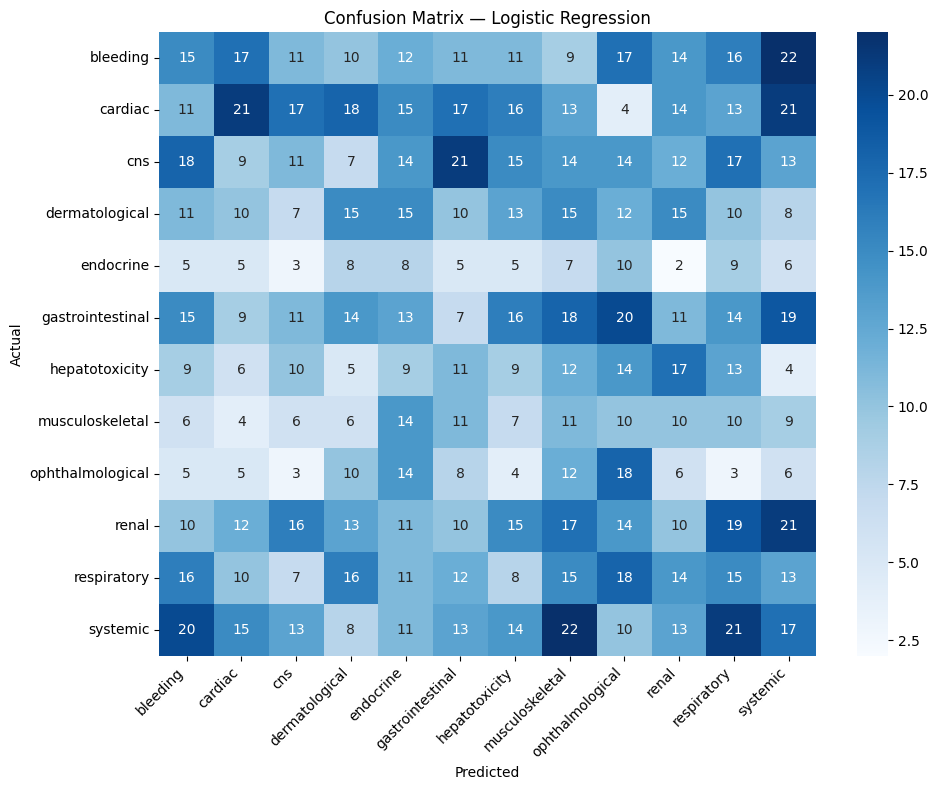

In [9]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True, fmt='d',
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    cmap='Blues', ax=ax
)
ax.set_title('Confusion Matrix — Logistic Regression')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Step 8 — 5-Fold Cross-Validation

Running 5-fold cross-validation...
CV F1 scores (5 folds): [0.0874 0.0974 0.0942 0.0901 0.0877]
Mean ± Std:             0.0913 ± 0.0039


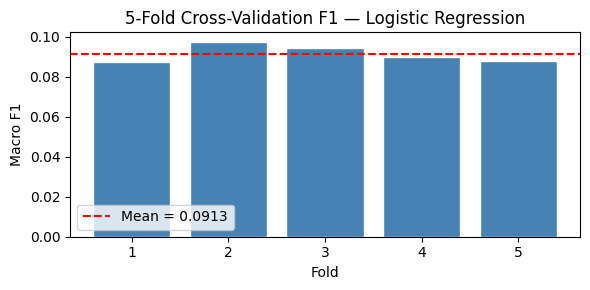

In [10]:
print('Running 5-fold cross-validation...')

cv_scores = cross_val_score(
    pipeline,
    X_train, y_train,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1
)

print(f'CV F1 scores (5 folds): {cv_scores.round(4)}')
print(f'Mean ± Std:             {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

# Plot CV scores
fig, ax = plt.subplots(figsize=(6, 3))
ax.bar(range(1, 6), cv_scores, color='steelblue', edgecolor='white')
ax.axhline(cv_scores.mean(), color='red', linestyle='--', label=f'Mean = {cv_scores.mean():.4f}')
ax.set_title('5-Fold Cross-Validation F1 — Logistic Regression')
ax.set_xlabel('Fold')
ax.set_ylabel('Macro F1')
ax.legend()
plt.tight_layout()
plt.show()

## Step 9 — Summary

In [11]:
summary = pd.DataFrame([{
    'Model':         'Logistic Regression',
    'Sample size':   f'{X.shape[0]:,}',
    'Accuracy':      round(acc, 4),
    'F1 (macro)':    round(f1_macro, 4),
    'F1 (weighted)': round(f1_weighted, 4),
    'CV F1 Mean':    round(cv_scores.mean(), 4),
    'CV F1 Std':     round(cv_scores.std(), 4),
}])

display(summary)

summary.to_csv('data/logistic_regression_results.csv', index=False)
print('Results saved to data/logistic_regression_results.csv')
print(f'\nGNN target: F1 > 0.75  (Logistic Regression = {f1_macro:.4f})')

,Model,Sample size,Accuracy,F1 (macro),F1 (weighted),CV F1 Mean,CV F1 Std
0,Logistic Regression,"8,536",0.0919,0.0918,0.0917,0.0913,0.0039


Results saved to data/logistic_regression_results.csv

GNN target: F1 > 0.75  (Logistic Regression = 0.0918)
